# Logistic Regression training and testing

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

## Load Titanic dataset



In [53]:
import seaborn as sns

df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


What we want to predict: survival rate

In [31]:
y = df["survived"]

In [32]:
y[:4]

0    0
1    1
2    1
3    1
Name: survived, dtype: int64

In [33]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]

X = df[features]

y = df["survived"]

X.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


The dataset has missing values.. so we need to fill them in with something.

In [34]:
X = X.copy()

X["age"] = X["age"].fillna(X["age"].median())
X["fare"] = X["fare"].fillna(X["fare"].median())
X["embarked"] = X["embarked"].fillna(X["embarked"].mode()[0])

X.isna().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Do you remember why we need to separate in train/test data?

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (712, 7)
Test size: (179, 7)


In [36]:
# numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
numeric_features = ["age"]
categorical_features = ["sex", "embarked"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [37]:
log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

log_reg.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
y_pred = log_reg.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0])

In [39]:
y_proba = log_reg.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.17162953, 0.14924305, 0.32777824, 0.15244057, 0.72230161,
       0.68075438, 0.68075438, 0.14818956, 0.2803091 , 0.16011989])

In [40]:
results = pd.DataFrame({
    "true_survived": y_test.values,
    "predicted_class": y_pred,
    "predicted_probability_survival": y_proba
})

results.head(10)

,true_survived,predicted_class,predicted_probability_survival
0,0,0,0.171630
1,0,0,0.149243
2,1,0,0.327778
3,0,0,0.152441
4,1,1,0.722302
5,1,1,0.680754
6,1,1,0.680754
7,0,0,0.148190
8,0,0,0.280309
9,0,0,0.160120


In [41]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")


Accuracy:  0.777
Precision: 0.738
Recall:    0.652
F1-score:  0.692


Accuracy = how often the model is correct

Precision = when the model predicts survived, how often is it right?

Recall = among people who survived, how many did the model find?

F1 = balance between precision and recall

In [42]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Did not survive", "Survived"]
))

                 precision    recall  f1-score   support

Did not survive       0.80      0.85      0.82       110
       Survived       0.74      0.65      0.69        69

       accuracy                           0.78       179
      macro avg       0.77      0.75      0.76       179
   weighted avg       0.77      0.78      0.77       179



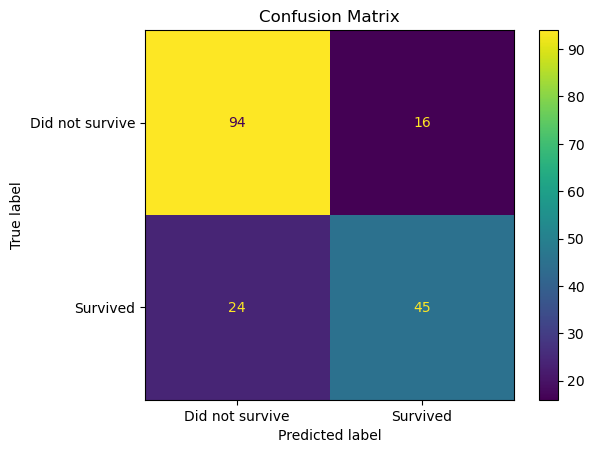

In [43]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did not survive", "Survived"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

1. What is the target variable?

2. Which features are numerical?

3. Which features are categorical?

4. Why do we use OneHotEncoder?

5. Why do we scale numerical features?

6. What does accuracy measure?

7. What does precision measure?

8. What does recall measure?

9. In the Titanic case, is recall important? Why?

10. Look at the coefficients. Which features increase the probability of survival?

11. Which features decrease the probability of survival?

12. Try removing features. How do the metrics change?


13. Try changing the decision threshold from 0.5 to 0.3. What happens to precision and recall?

In [44]:
threshold = 0.3

y_pred_threshold = (y_proba >= threshold).astype(int)

print(f"Metrics with threshold = {threshold}")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_threshold):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_threshold):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_threshold):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_threshold):.3f}")

Metrics with threshold = 0.3
Accuracy:  0.743
Precision: 0.649
Recall:    0.725
F1-score:  0.685


Let's plot the decision lines

In [51]:
# Get the trained logistic regression classifier from the pipeline
classifier = log_reg.named_steps["classifier"]

# Transform X_test using the fitted preprocessor
X_test_transformed = log_reg.named_steps["preprocessor"].transform(X_test)

# Compute the linear score z = Xw + b --> this is what decision_function does, not really used in practice
z = classifier.decision_function(X_test_transformed)

# Compute sigmoid
p_manual = 1 / (1 + np.exp(-z))

# Get probabilities from sklearn
p_sklearn = log_reg.predict_proba(X_test)[:, 1]

# Check that they are the same
print("Manual sigmoid probabilities:")
print(p_manual[:10])

print("\nSklearn probabilities:")
print(p_sklearn[:10])

Manual sigmoid probabilities:
[0.17162953 0.14924305 0.32777824 0.15244057 0.72230161 0.68075438
 0.68075438 0.14818956 0.2803091  0.16011989]

Sklearn probabilities:
[0.17162953 0.14924305 0.32777824 0.15244057 0.72230161 0.68075438
 0.68075438 0.14818956 0.2803091  0.16011989]


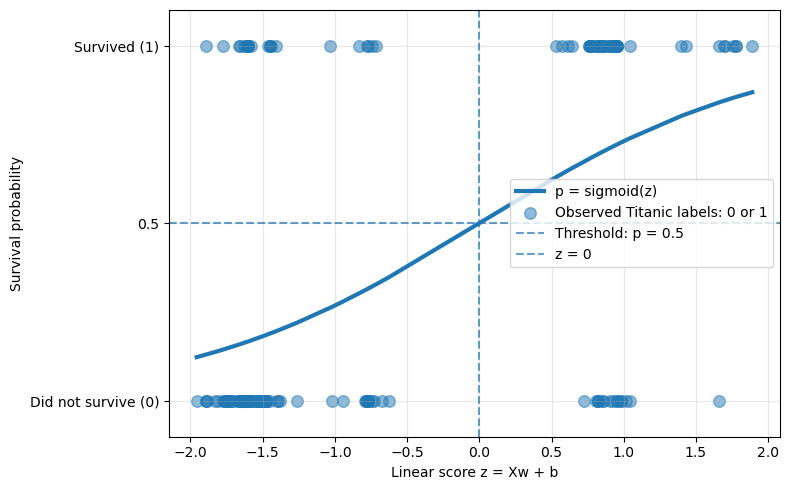

In [52]:
# Sort values so the curve is smooth
order = np.argsort(z)

z_sorted = z[order]
p_sorted = p_manual[order]

plt.figure(figsize=(8, 5))

plt.plot(
    z_sorted,
    p_sorted,
    linewidth=3,
    label="p = sigmoid(z)"
)

plt.scatter(
    z,
    y_test,
    s=70,
    alpha=0.5,
    label="Observed Titanic labels: 0 or 1"
)

plt.axhline(
    0.5,
    linestyle="--",
    alpha=0.7,
    label="Threshold: p = 0.5"
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.7,
    label="z = 0"
)

plt.xlabel("Linear score z = Xw + b")
plt.ylabel("Survival probability")

plt.yticks([0, 0.5, 1], ["Did not survive (0)", "0.5", "Survived (1)"])
plt.ylim(-0.1, 1.1)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()